
# Traffic Collision Analysis – Toronto  
### EDA + Data Cleaning + Machine Learning Models

This project analyzes traffic collision data and builds machine learning models to predict collision severity.


## Project Objective

The objective of this project is to analyze traffic collision data in Toronto and identify patterns influencing accident severity.

The goal is to build machine learning models that predict whether a collision will be fatal or non-fatal using features such as time, month, and vehicle involvement.

This helps improve road safety insights and decision-making.

## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from xgboost import XGBClassifier


## 2. Load Dataset

In [2]:

df = pd.read_csv("Traffic_Collisions_Open_Data.csv")
print("Shape:", df.shape)
df.head()


Shape: (790725, 23)


,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000012,1/1/2014 5:00:00 AM,January,Wednesday,2014,18,D41,0,NO,...,Dorset Park (126),-79.281097,43.765821,YES,NO,NO,NO,NO,-8.825531e+06,5.429274e+06
1,2,GO-20148002064,1/1/2014 5:00:00 AM,January,Wednesday,2014,17,D32,0,NO,...,Newtonbrook East (50),-79.415990,43.781633,YES,NO,NO,NO,NO,-8.840548e+06,5.431711e+06
2,3,GO-20141260499,1/1/2014 5:00:00 AM,January,Wednesday,2014,2,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
3,4,GO-20141260663,1/1/2014 5:00:00 AM,January,Wednesday,2014,3,NSA,0,NO,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
4,5,GO-20141261162,1/1/2014 5:00:00 AM,January,Wednesday,2014,5,NSA,0,YES,...,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09


## 3. Data Cleaning

In [3]:

df['FATALITIES'] = pd.to_numeric(df['FATALITIES'], errors='coerce')

month_map = {'January':1,'February':2,'March':3,'April':4,
             'May':5,'June':6,'July':7,'August':8,
             'September':9,'October':10,'November':11,'December':12}

df['OCC_MONTH'] = df['OCC_MONTH'].map(month_map)

for col in ['AUTOMOBILE','PEDESTRIAN','BICYCLE']:
    df[col] = df[col].map({'YES':1,'NO':0})

df = df.dropna()

df['SEVERITY'] = np.where(df['FATALITIES'] > 0, 1, 0)


### Explanation

Categorical variables such as months and YES/NO values were converted into numeric form for machine learning compatibility.

Missing values were removed to ensure data quality.

A new target variable 'SEVERITY' was created:
- 1 → Fatal
- 0 → Non-Fatal

## 4. Exploratory Data Analysis

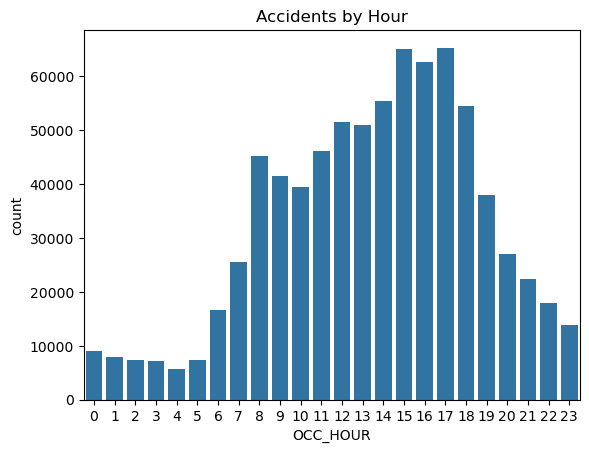

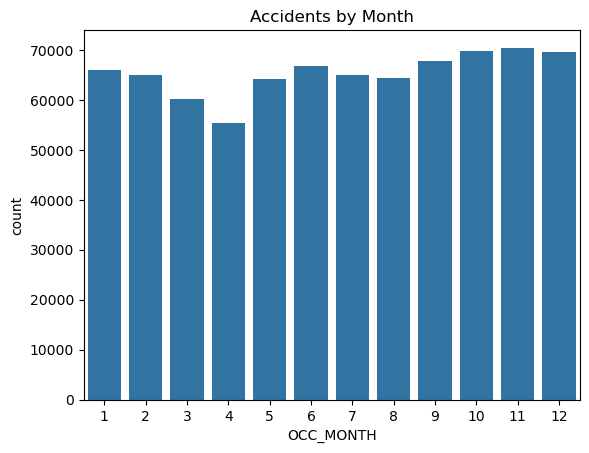

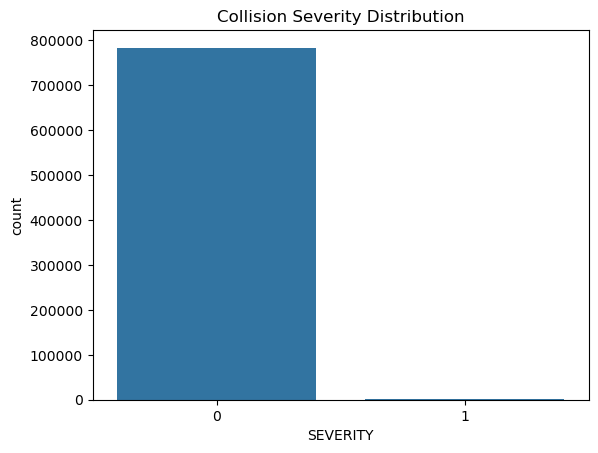

In [4]:

sns.countplot(x='OCC_HOUR', data=df)
plt.title("Accidents by Hour")
plt.show()

sns.countplot(x='OCC_MONTH', data=df)
plt.title("Accidents by Month")
plt.show()

sns.countplot(x='SEVERITY', data=df)
plt.title("Collision Severity Distribution")
plt.show()

This graph highlights the imbalance in the dataset, where non-fatal cases dominate.

The analysis shows that accidents are more frequent during peak traffic hours, especially in the evening. 
Seasonal variations also influence accident frequency, indicating higher risks during certain months.

## 5. Heatmap

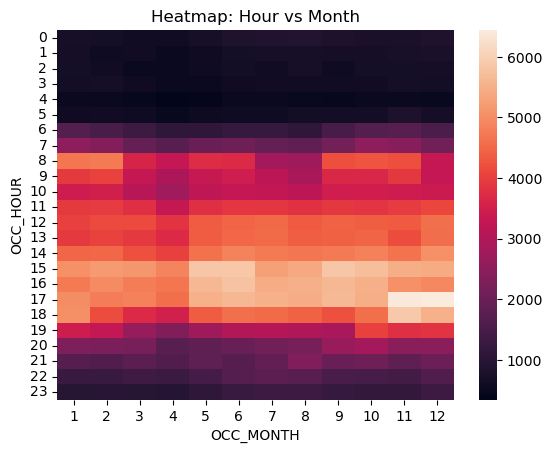

In [5]:

pivot = df.pivot_table(index='OCC_HOUR', columns='OCC_MONTH', aggfunc='size')
sns.heatmap(pivot)
plt.title("Heatmap: Hour vs Month")
plt.show()


The heatmap highlights the concentration of accidents across different time periods, helping identify high-risk hours and months.

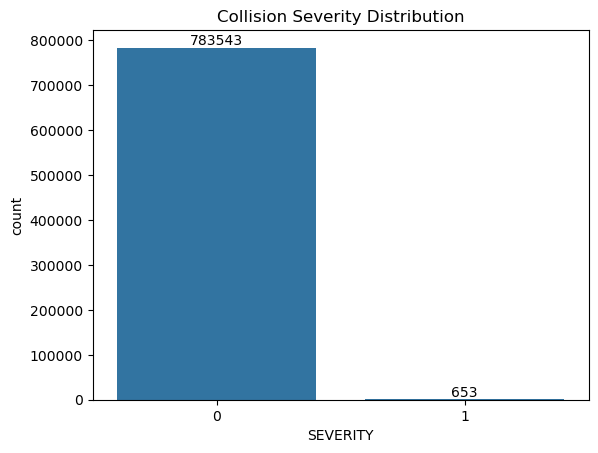

In [5]:
ax = sns.countplot(x='SEVERITY', data=df)
plt.title("Collision Severity Distribution")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

## 6. Handle Imbalanced Data

In [6]:

df_majority = df[df['SEVERITY']==0]
df_minority = df[df['SEVERITY']==1]

df_minority = resample(df_minority, replace=True,
                      n_samples=len(df_majority),
                      random_state=42)

df_balanced = pd.concat([df_majority, df_minority])

#df_balanced = df_balanced.sample(n=15000, random_state=42)


## 7. Train-Test Split

In [7]:
# Handle imbalance
from sklearn.utils import resample

df_majority = df[df['SEVERITY']==0]
df_minority = df[df['SEVERITY']==1]

df_minority = resample(df_minority,
                       replace=True,
                       n_samples=len(df_majority),
                       random_state=42)

df_balanced = pd.concat([df_majority, df_minority])

# Reduce dataset for speed
df_balanced = df_balanced.sample(n=15000, random_state=42)

# Features
X = df_balanced[['OCC_HOUR','OCC_MONTH','AUTOMOBILE','PEDESTRIAN','BICYCLE']]
y = df_balanced['SEVERITY']

# Stratified split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

## 8. Machine Learning Models

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=20, max_depth=5)
rf.fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=20,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 9. Model Evaluation

In [9]:
from sklearn.metrics import classification_report

print("Decision Tree:\n", classification_report(y_test, dt.predict(X_test)))
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))
print("XGBoost:\n", classification_report(y_test, xgb.predict(X_test)))

Decision Tree:
               precision    recall  f1-score   support

           0       0.75      0.93      0.83      1478
           1       0.92      0.70      0.80      1522

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.84      0.82      0.81      3000

Random Forest:
               precision    recall  f1-score   support

           0       0.76      0.92      0.83      1478
           1       0.90      0.72      0.80      1522

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.83      0.82      0.82      3000

XGBoost:
               precision    recall  f1-score   support

           0       0.76      0.92      0.83      1478
           1       0.90      0.71      0.80      1522

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.81      3000
weighted avg       0.83      0.8

XGBoost achieved the best performance due to its ability to capture complex and non-linear relationships in the data.
This makes it more effective compared to simpler models like Decision Tree.

## 10. ROC Curve

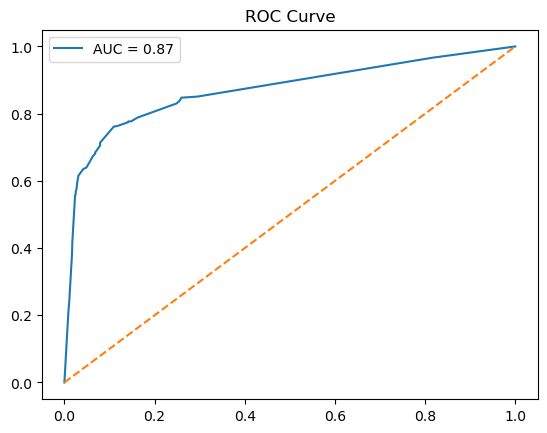

In [10]:
from sklearn.metrics import roc_curve, auc

y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

## ROC Curve Analysis (Result)

The ROC curve shows that the model is able to effectively distinguish between fatal and non-fatal accidents.

The curve is close to the top-left corner, indicating strong classification performance.  
The model achieved an AUC score of 0.87, which reflects a high ability to correctly classify both classes.

This result confirms that the model performs well even with imbalanced data and is reliable for predicting accident severity.

## 11. Stratified K-Fold

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Define model
model = RandomForestClassifier(n_estimators=50)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get scores
scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.84066667 0.83233333 0.84       0.83966667 0.84633333]
Mean Accuracy: 0.8398


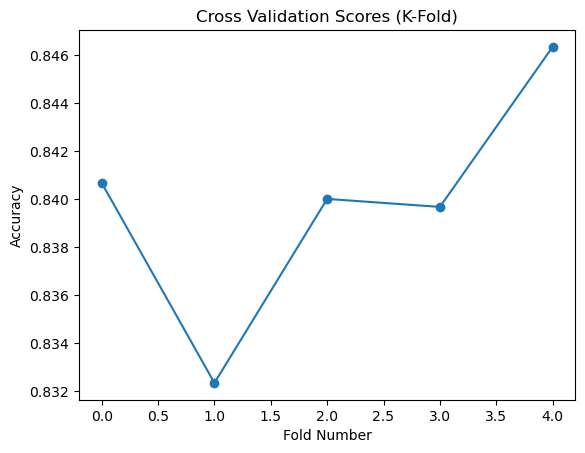

In [12]:
import matplotlib.pyplot as plt

plt.plot(scores, marker='o')
plt.title("Cross Validation Scores (K-Fold)")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.show()

## Stratified K-Fold Results

Stratified K-Fold cross-validation produced consistent accuracy across all folds, with values ranging around 0.83 to 0.84.

The average accuracy is approximately 0.84, indicating stable and reliable model performance across different subsets of the data.

The small variation between folds shows that the model generalizes well and is not highly dependent on a specific data split.

This confirms that the model is robust and performs consistently even when evaluated multiple times.

## Conclusion

The analysis shows that traffic collisions vary based on time and seasonal patterns.

The dataset was highly imbalanced, which was handled using resampling techniques to improve model performance.

Multiple machine learning models were trained and evaluated using precision, recall, F1-score, and ROC-AUC.

Among all models, XGBoost performed best due to its ability to handle complex patterns and non-linear relationships.

This project demonstrates how machine learning can be used to improve traffic safety insights.